In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import qr, pinv
from scipy.linalg import solve_triangular


np.random.seed(42)

# LOESS
Рассмотрим обыкновенную линейную регрессию. Её формула:

$$
y_i = f(x_i) + \epsilon_i,
$$

где

$$
f(x_i) = \beta_0 + \beta_1 \cdot x_i.
$$

Однако рассмотрим данные следующего вида:

In [2]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)

<Axes: >

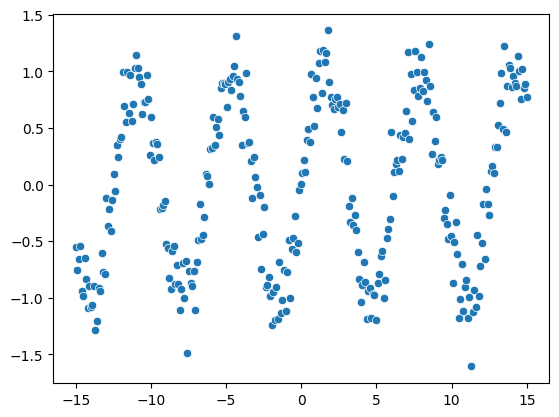

In [3]:
sns.scatterplot(x=x, y=y)

Попробуем обучить модель линейной модели на этих данных

<Axes: >

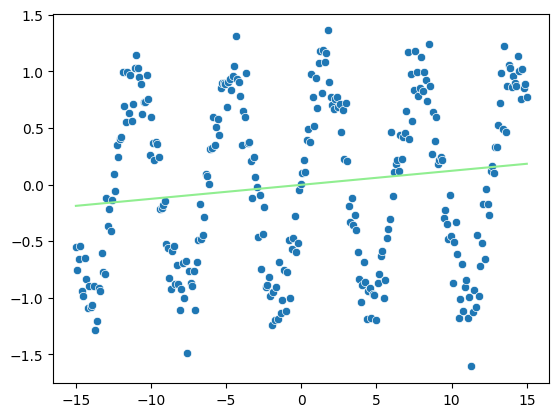

In [4]:
lin = LinearRegression().fit(x.reshape(-1, 1), y)
preds_lin = lin.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds_lin, color="lightgreen")

Кажется, что линейная модель никак не может выявить зависимость в данных. Одно из возможных решений - полиномиальная регрессия. Как думаете, какая степень полинома понадобится?

<Axes: >

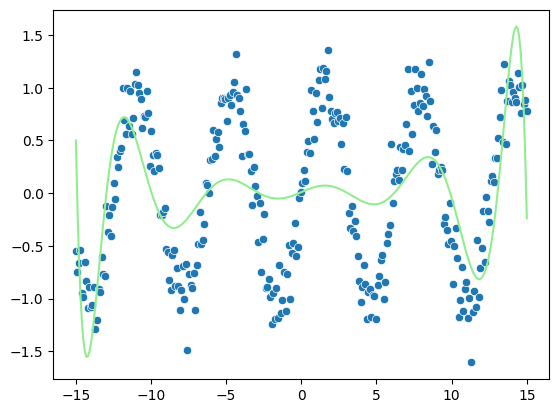

In [5]:
pipe = make_pipeline( PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1),y)
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")

Кажется, что для таких данных построить единую модель будет чрезвычайно сложно. Как можно решить такую проблему? Одно из решений - каким-то образом взвесить семплы, чтобы семплы ближе к переломам были более важны.

<Axes: >

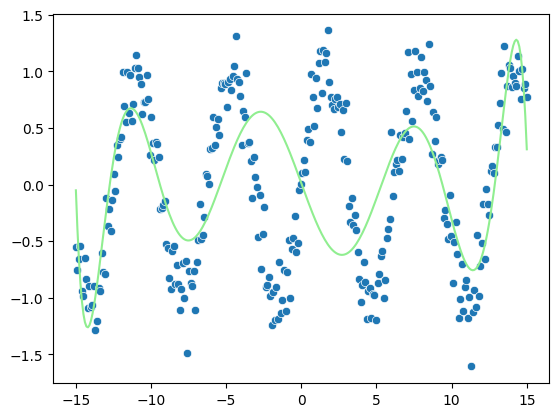

In [6]:
#Обучите с более высокой степенью

pipe = make_pipeline( PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1), y,  linearregression__sample_weight=abs(x))
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")


Выглядит уже ближе. Однако как бы нам сделать процесс взвешивания автоматическим? Рассмотрим модель взвешенной регрессии.

## Ядровая регрессия Надарая–Уотсона

Рассмотрим непараметрическую постановку $y_i = f(x_i) + \varepsilon_i$, где $f$ не фиксируется заранее конечномерным набором параметров.

**Ядерная регрессия Надарая–Уотсона (NW)** в точке $x$ задаёт оценку $\hat f(x)$ как взвешенное среднее значений $y_i$: вклад $i$-й точки убывает с ростом $|x-x_i|$, а вид этого убывания задаётся **ядром** $K$.

Ядро — это невозрастающая гладкая и ограниченная функция двух точек входа $k(x,x')$, которая задаёт, насколько они «похожи» относительно выбранного понятия расстояния между $x$ и $x'$. В идеале, эта функция должа удовлетворять еще двум свойствам - равенству интеграла единице и симметрии относительно 0. 

В NW используется одномерный вид $K_h(x-x_i)$ по разности между точкой оценки и наблюдением. При этом в разных методах ядро может трактоваться немного по-разному. В нашем случае эта функция задает веса регрессии (среднего).

Используем **трикубическое ядро**. Положим $u_i(x)=|x-x_i|/h$, где h - ширина окна. Тогда
$$
K_h(x-x_i)=\bigl(1-u_i(x)^3\bigr)_+^3\quad\text{при }u_i(x)<1,\qquad 0\ \text{ иначе}.
$$
У такого ядра **компактный носитель**: ненулевой вклад будет получен только при $|x-x_i|<h$.


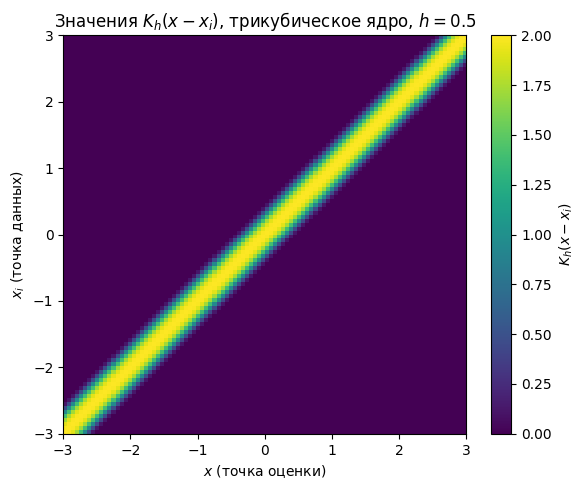

In [7]:
def tricubic_kernel_u(u: np.ndarray) -> np.ndarray:
    u = np.abs(u)
    out = np.zeros_like(u, dtype=float)
    m = u < 1.0
    out[m] = (1 - u[m]**3)**3
    return out


n: int = 100
x_grid = np.linspace(-3.0, 3.0, n)
h: float = 0.5
X_i = x_grid[:, None]
X_j = x_grid[None, :]
diff_signed = (X_j - X_i) / h
K_mat = tricubic_kernel_u(diff_signed) / h

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    K_mat,
    origin="lower",
    extent=(x_grid.min(), x_grid.max(), x_grid.min(), x_grid.max()),
    aspect="auto",
    cmap="viridis",
)
ax.set_xlabel("$x$ (точка оценки)")
ax.set_ylabel("$x_i$ (точка данных)")
ax.set_title(f"Значения $K_h(x-x_i)$, трикубическое ядро, $h={h}$")
fig.colorbar(im, ax=ax, label="$K_h(x-x_i)$")
plt.tight_layout()
plt.show()


Оценка Надарая–Уотсона:

$$
\hat{f}_{\mathrm{NW}}(x)=\frac{\sum_{i=1}^n K_h(x-x_i)\,y_i}{\sum_{i=1}^n K_h(x-x_i)}.
$$

Если положить $w_i(x)=K_h(x-x_i)/\sum_{j=1}^n K_h(x-x_j)$, то $\sum_i w_i(x)=1$ и $\hat{f}_{\mathrm{NW}}(x)=\sum_i w_i(x)\,y_i$.


**Алгоритм NW** для некоторого набора точек $x$ будет иметь вид:

1. Зафиксировать ядро и полосу $h$.
2. Для каждого $x$ вычислить $K_h(x-x_i)$ для всех $i=1,\ldots,n$.
3. Вычислить $\hat f_{\mathrm{NW}}(x)$ по формуле выше.
4. Повторить шаги 2–3 для всех $x$.

Посмотрим, что мы получим для нашей задачи, если используем ядерную регрессию:

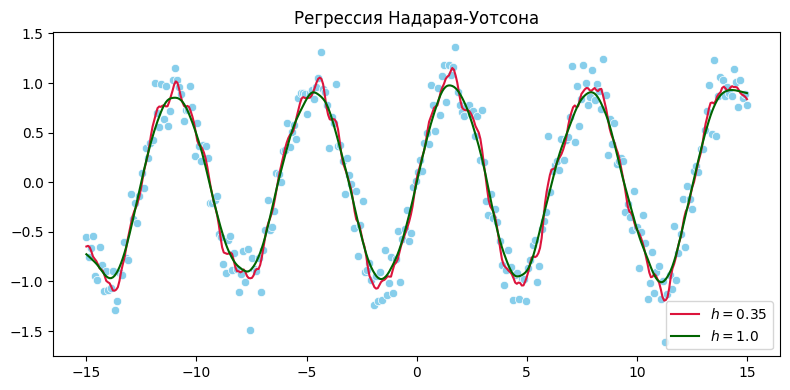

In [8]:
def nw_predict(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    h: float,
) -> np.ndarray:
    u = np.abs(x_query[:, None] - x_train[None, :]) / h
    w = tricubic_kernel_u(u)
    wy = (w * y_train[None, :]).sum(axis=1)
    s = w.sum(axis=1)
    return np.where(s > 0, wy / s, np.nan)


h_narrow = 0.35
h_wide = 1.0
x_query = np.linspace(float(x.min()), float(x.max()), 400)
y_nw_n = nw_predict(x, y, x_query, h_narrow)
y_nw_w = nw_predict(x, y, x_query, h_wide)

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=x, y=y, ax=ax, color="skyblue")
sns.lineplot(x=x_query, y=y_nw_n, ax=ax, color="crimson", label=f"$h={h_narrow}$")
sns.lineplot(x=x_query, y=y_nw_w, ax=ax, color="darkgreen", label=f"$h={h_wide}$")
ax.legend()
ax.set_title(
    "Регрессия Надарая-Уотсона"
)
plt.tight_layout()
plt.show()


При этом мы можем увидеть, что у краёв оценка NW  имеет смещение, так как у крайних семплов нет соседей с обеих сторон.  К выбросам NW также чувствителен: один большой $y_i$ заметно тянет кривую в своей полосе. Рассмотрим это отдельно чуть подробнее:


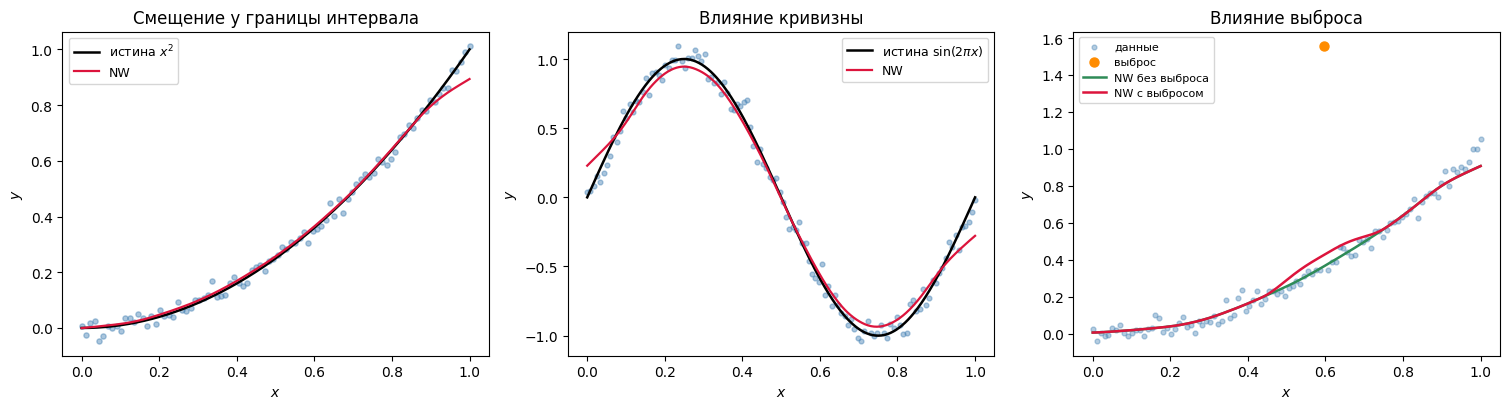

In [9]:
rng = np.random.default_rng(42)
x_edge = np.linspace(0.0, 1.0, 90)
y_edge = x_edge**2 + rng.normal(0.0, 0.025, size=x_edge.shape)
x_q01 = np.linspace(0.0, 1.0, 400)
h_edge: float = 0.18
nw_edge = nw_predict(x_edge, y_edge, x_q01, h_edge)

x_sin = np.linspace(0.0, 1.0, 120)
y_sin = np.sin(2 * np.pi * x_sin) + rng.normal(0.0, 0.06, size=x_sin.shape)
h_sin: float = 0.14
nw_sin = nw_predict(x_sin, y_sin, x_q01, h_sin)

x_out = np.linspace(0.0, 1.0, 100)
y_out_clean = x_out**2 + rng.normal(0.0, 0.03, size=x_out.shape)
outlier_idx = np.argmin(np.abs(x_out - 0.6))
y_out_with = y_out_clean.copy()
y_out_with[outlier_idx] += 1.2
h_out: float = 0.17
nw_out_clean = nw_predict(x_out, y_out_clean, x_q01, h_out)
nw_out_with = nw_predict(x_out, y_out_with, x_q01, h_out)

fig, (axb, axc, axd) = plt.subplots(1, 3, figsize=(15.2, 4.2))
axb.scatter(x_edge, y_edge, s=14, alpha=0.45, color="steelblue")
axb.plot(x_q01, x_q01**2, color="black", linewidth=1.8, label="истина $x^2$")
axb.plot(x_q01, nw_edge, color="crimson", linewidth=1.6, label="NW")
axb.set_title("Смещение у границы интервала")
axb.set_xlabel("$x$")
axb.set_ylabel("$y$")
axb.legend(loc="upper left", fontsize=9)

axc.scatter(x_sin, y_sin, s=12, alpha=0.45, color="steelblue")
axc.plot(x_q01, np.sin(2 * np.pi * x_q01), color="black", linewidth=1.8, label=r"истина $\sin(2\pi x)$")
axc.plot(x_q01, nw_sin, color="crimson", linewidth=1.6, label="NW")
axc.set_title("Влияние кривизны")
axc.set_xlabel("$x$")
axc.set_ylabel("$y$")
axc.legend(loc="upper right", fontsize=9)

axd.scatter(x_out, y_out_with, s=12, alpha=0.4, color="steelblue", label="данные")
axd.scatter(x_out[outlier_idx], y_out_with[outlier_idx], s=42, color="darkorange", zorder=4, label="выброс")
axd.plot(x_q01, nw_out_clean, color="seagreen", linewidth=1.8, label="NW без выброса")
axd.plot(x_q01, nw_out_with, color="crimson", linewidth=1.8, label="NW с выбросом")
axd.set_title("Влияние выброса")
axd.set_xlabel("$x$")
axd.set_ylabel("$y$")
axd.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


Поэтому мы можем перейти к чуть более сложному методу: что если веса в каждой точке будут получаться не через простое взвешиваение, а через полиномиальную (или линейную) регрессию? 

Рассмотрим постановку задачи взвешенной полиномиальной регрессии $\hat{y_i} = (\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots)$:
$$
\sum_i w_i(x_0)\,\bigl(y_i - (\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots)\bigr)^2 \rightarrow \min_{\beta}.
$$


1. Обозначим через $x_i$ набор $n$ значений признаков (сейчас для 1 переменной) и пусть $y_i$ представляет соответствующие целевые значения.

2. Найдём ближайшие точки к целевой точке $x_0$. Обозначим это множество $D_0$. (Важно учесть расстояния до них: $d_{i0}$).

3. Найдём самое большое расстояние между этими точками. Обозначим эту величину $\delta(x_0)$.

4. Вычислим весовую функцию $w_i$ для каждого $x_i \in D_0$, используя соотношение

    $$
    w_i(x_0) = W\left(\frac{d_{i0}}{\delta(x_0)}\right),
    $$

    где $W(u)$ некоторое ядро (снова!). Используем трикуб:

    $$
    W(u) =
    \begin{cases}
    (1 - u^3)^3, & 0 \leq u < 1 \\
    0, & \text{иначе.}
    \end{cases}
    $$

5. Оценку $\hat{f}(x_0)$ получают из взвешенных МНК. В матричном виде, с диагональной матрицей весов $W$ и матрицей признаков $X$:

$$
\begin{align}
W X \hat{\beta} &= W y \\
X^{\mathsf T} W X \hat{\beta} &= X^{\mathsf T} W y \\
\hat{\beta} &= (X^{\mathsf T} W X)^{-1} X^{\mathsf T} W y
\end{align}
$$

LOESS сочетает в себе простоту линейной (полиномиальной) регрессии с универсальностью непараметрических методов. При этом метод получается достаточно гибким за счет возможностей выбора степеней полинома, ядра и его параметров.

Так, можно задать ширину пропускания числом соседей, которые будут использоваться для расчётов. Для начала воспользуемся таким способом. 


Реализуем метод локальной регрессии. Это придётся делать в несколько этапов. Так, нам необходимо решить уравнение

$$
W X \hat{\beta} = W y
$$

(эквивалентно нормальным уравнениям $X^{\mathsf T} W X \hat{\beta} = X^{\mathsf T} W y$).

In [10]:
def solve(x, y, W, deg: int = 1):
    A = np.vander(x, N=1+deg)
    W_diag = np.diag(W) if W.ndim == 2 else W
    V = A.T @ (W_diag[:, None] * A)
    Y = A.T @ (W_diag * y)
    Q, R = qr(V)
    p = solve_triangular(R, np.matmul(Q.T, Y))
    return p


Напишем функцию, задающую нашу полосу пропускания и определяющую, какие точки в неё попали:


In [11]:
def tricubic_kernel_u(u: np.ndarray) -> np.ndarray:
    u = np.abs(u)
    out = np.zeros_like(u, dtype=float)
    m = u < 1.0
    out[m] = (1 - u[m]**3)**3
    return out

def nw_predict(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    h: float,
) -> np.ndarray:
    u = np.abs(x_query[:, None] - x_train[None, :]) / h
    w = tricubic_kernel_u(u)
    s = w.sum(axis=1)
    wy = (w * y_train[None, :]).sum(axis=1)
    return np.where(s > 0, wy / s, np.nan)

def solve(x, y, W, deg: int = 1):
    A = np.vander(x, N=1+deg)
    V = (A.T * W) @ A
    Y = A.T @ (W * y)
    Q, R = qr(V)
    p = solve_triangular(R, np.matmul(Q.T, Y))
    return p

def get_span(x: np.array, y: np.array, x_target: float, k: int) -> tuple[np.typing.NDArray, np.typing.NDArray, np.typing.NDArray]:
    distance = np.abs(x - x_target)
    sorted_dist = np.sort(distance)
    ind = np.argsort(distance)

    ind_span = ind[:k]
    x_span = x[ind_span]
    y_span = y[ind_span]
    delta_0 = sorted_dist[k-1]
    u = distance[ind_span] / delta_0
    return u, x_span, y_span, ind_span

И соберем финальную функцию.

In [12]:
def loess_tricub(x, y, k, deg):
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3
        p = solve(x_span, y_span, w, deg=deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target
    return y_hat, x_space


Построим графики предсказаний для разных K.

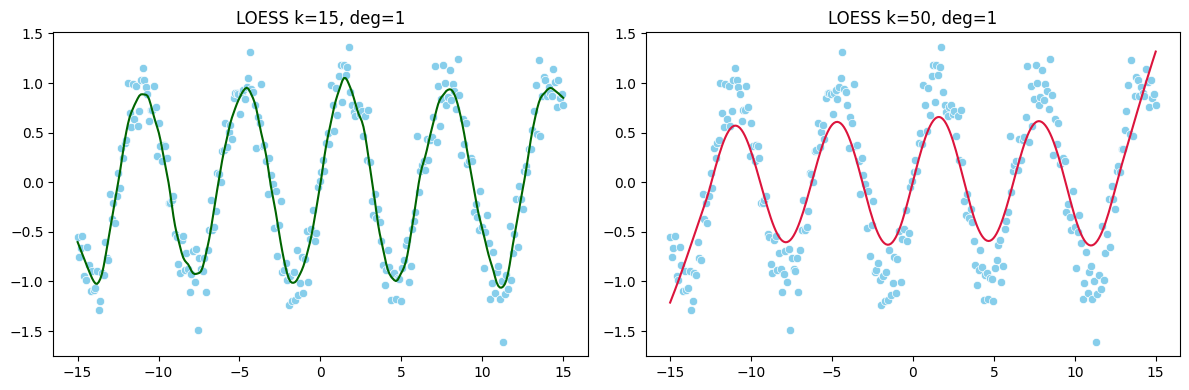

MSE k=15: 0.034864642797505056
MSE k=50: 0.11276147926847695


In [13]:
y_pred_small, x_pred_small = loess_tricub(x, y, k=15, deg=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[0])
sns.lineplot(x=x_pred_small, y=y_pred_small, color='darkgreen', ax=axes[0])
axes[0].set_title(f'LOESS k=15, deg=1')

y_pred_big, x_pred_big = loess_tricub(x, y, k=50, deg=1)
sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[1])
sns.lineplot(x=x_pred_big, y=y_pred_big, color='crimson', ax=axes[1])
axes[1].set_title(f'LOESS k=50, deg=1')

plt.tight_layout()
plt.show()

print("MSE k=15:", mean_squared_error(y, y_pred_small))
print("MSE k=50:", mean_squared_error(y, y_pred_big))

error =  0.03758271258545037


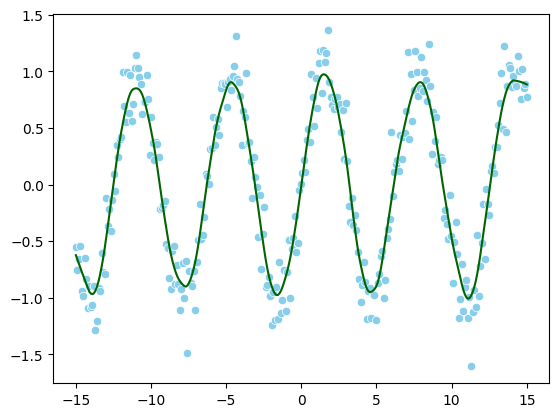

In [14]:
# make loess regression with bigger k and plots
y_pred, x_pred = loess_tricub(x, y, k=20, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color ='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color ='darkgreen')
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Чем больше k, тем более сглаженным получается решение. Но можно, например, перейти к бьоле гибком выбору полосы пропускания, которой мы уже пользовались в методе Надарая-Уотсона и использовать пропорцию от размера датасета. Реализуем это.

In [15]:
def get_k_relative(alpha: float, n: int):
    return max(3, int(alpha * n))

def loess_tricub_alpha(x, y, alpha, deg):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3
        p = solve(x_span, y_span, w, deg=deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target

    return y_hat, x_space

error =  0.5084280660749577


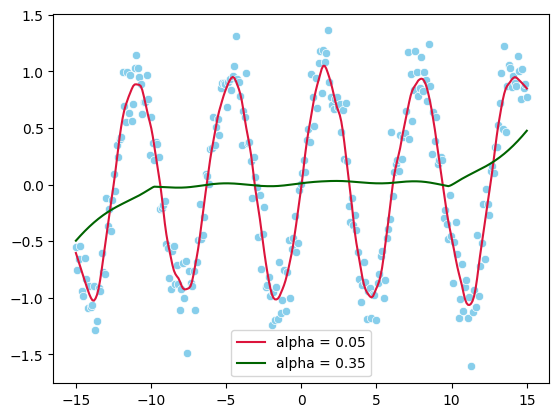

In [16]:
alpha_narrow = 0.05
alpha_wide = 0.35
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_narrow, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color ='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color ='crimson', label=f"alpha = {alpha_narrow}")
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_wide, deg=1)
sns.lineplot(x=x_pred, y=y_pred, color ='darkgreen', label=f"alpha = {alpha_wide}")
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Можно ли использовать другие функции в качестве весовых? Да, например, воспользуемся колоколообразным (гауссовым) ядром:

$$
w^{(i)} = \exp\left( -\frac{(x^{(i)} - x)^2}{2\tau^2} \right).
$$

Параметр $\tau$ выполняет ту же роль, что у полосы $h$ в блоке про ядерную регрессию NW выше и контролирует, насколько быстро вес обучающего примера падает с увеличением расстояния до точки $x$, и называется параметром *bandwidth*. Вопрос: как меняется форма «колокола» при увеличении $\tau$?

In [17]:
def loess(x, y, kernel, alpha, deg, **kernel_params):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = kernel(u, **kernel_params)
        p = solve(x_span, y_span, w, deg=deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target

    return x_space, y_hat

Ещё один классический пример — гауссово (RBF) ядро на $\mathbb{R}^p$:
$$
k(x,x')=\sigma^2\exp\left(-\frac{1}{2\ell^2}\|x-x'\|^2\right).
$$
Параметр $\ell$ задаёт горизонтальный масштаб, $\sigma^2$ — вертикальный.

Такие ядра используют при задании ковариаций в гауссовских процессах и в методе опорных векторов (SVM).

Вообще разнообразных ядер достаточно много:

На нормированном расстоянии $u = d/\delta \in [0,1]$ часто используются:

- **трикуб**: $(1-u^3)^3$ при $u<1$;
- **Epanechnikov**: ${3 \over 4} (1-u^2)$;
- **биквадратное** (квадратичное): ${15 \over 16} (1-u^2)^2$;
- **триквадратное** (квадратичное): ${32 \over 33} (1-u^2)^3$;
- **треугольное**:  $(1-|u|)$;
- **равномерное**: $\mathbf{1}_{[0,1]}(u)$;
- **гауссово**: ${1 \over \sqrt{2\pi}} \exp(-{1 \over 2 } u^2)$; параметр $\tau$ задаёт ширину «колокола» (см. график справа).

Ниже слева — кривые нескольких ядер как функций $u$; справа — гауссово $K(d)$ при разных $\tau$. Затем — **сравнение тепловых карт** $K_h(x,x_i)$ на одной сетке и при одном $h$ для трикуба и гаусса: у трикуба носитель компактен, у гаусса — бесконечный хвост.

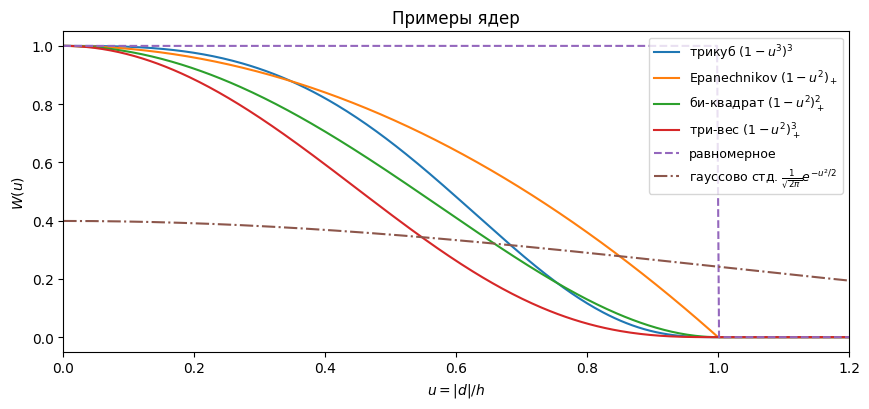

In [18]:
u_grid = np.linspace(0, 1.2, 400)
tricub = np.where((u_grid >= 0) & (u_grid < 1), (1 - u_grid**3) ** 3, 0.0)
epa = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2), 0.0)
bisq = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 2, 0.0)
triw = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 3, 0.0)
unif = np.where((u_grid >= 0) & (u_grid <= 1), 1.0, 0.0)
gau_std = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u_grid**2)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.2))
ax.plot(u_grid, tricub, label="трикуб $(1-u^3)^3$")
ax.plot(u_grid, epa, label="Epanechnikov $(1-u^2)_+$")
ax.plot(u_grid, bisq, label="би-квадрат $(1-u^2)_+^2$")
ax.plot(u_grid, triw, label="три-вес $(1-u^2)_+^3$")
ax.plot(u_grid, unif, linestyle="--", label="равномерное")
ax.plot(u_grid, gau_std, linestyle="-.", label="гауссово стд. $\\frac{1}{\\sqrt{2\\pi}}e^{-u^2/2}$")
ax.set_xlabel("$u = |d|/h$")
ax.set_ylabel("$W(u)$")
ax.set_title("Примеры ядер")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1.2)
plt.tight_layout()
plt.show()

Задание: постройте тепловые карты для гауссовского, равномерного и любого другого ядер

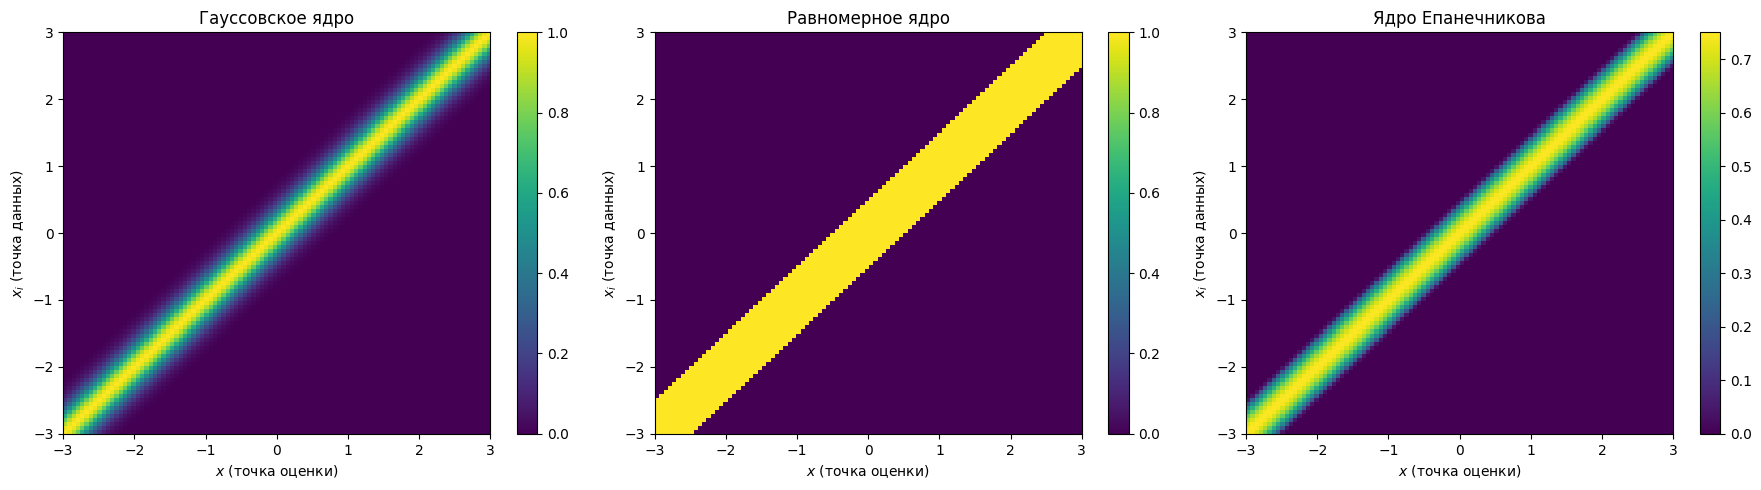

In [19]:
def gaussian_kernel(u, sigma=1.0):
    return np.exp(-0.5 * (u / sigma)**2)

def uniform_kernel(u):
    return np.where(u <= 1.0, 1.0, 0.0)

def epanechnikov_kernel(u):
    return np.where(u <= 1.0, 0.75 * (1 - u**2), 0.0)

x_grid = np.linspace(-3.0, 3.0, 100)
h = 0.5
X_i = x_grid[:, None]
X_j = x_grid[None, :]
diff_signed = (X_j - X_i) / h
u = np.abs(diff_signed)

K_gauss = gaussian_kernel(u, sigma=0.5)
K_uniform = uniform_kernel(u)
K_epa = epanechnikov_kernel(u)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernels = [K_gauss, K_uniform, K_epa]
titles = ['Гауссовское ядро', 'Равномерное ядро', 'Ядро Епанечникова']

for ax, K, title in zip(axes, kernels, titles):
    im = ax.imshow(K, origin='lower', 
                   extent=(x_grid.min(), x_grid.max(), x_grid.min(), x_grid.max()),
                   aspect='auto', cmap='viridis')
    ax.set_xlabel("$x$ (точка оценки)")
    ax.set_ylabel("$x_i$ (точка данных)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [20]:
def tricub_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, (1 - abs_dist**3) ** 3, 0.0)

def bell_kernel(dist: np.ndarray, tau: float) -> np.ndarray:
    return np.exp(-(dist**2) / (2 * tau**2))


error =  0.034864642797505056


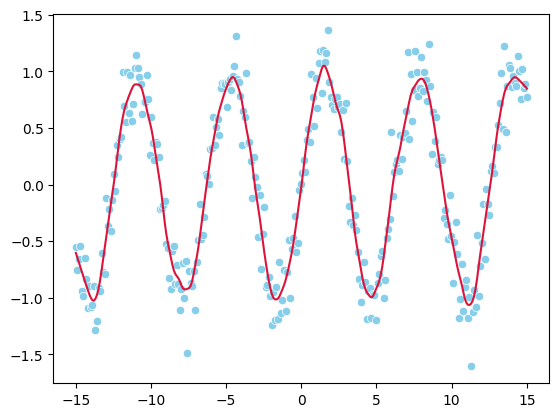

In [21]:
x_est, y_est = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_est, y=y_est, color='crimson')
print("error = ", mean_squared_error(y_true=y, y_pred=y_est))

error tricub =  0.034864642797505056
error bell =  0.03087405446364368


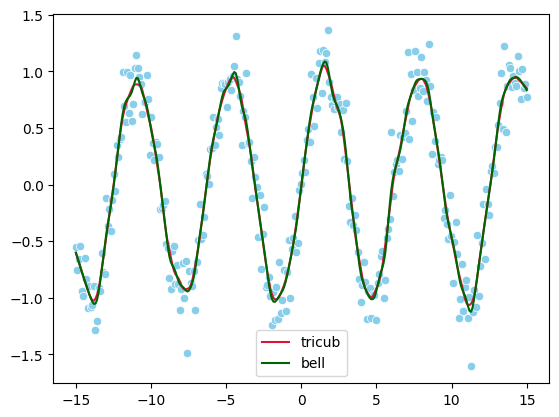

In [22]:
tau = 0.3

fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')

x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", label='tricub')
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_est_tricub))

x_est_bell, y_est_bell = loess(x, y, kernel=bell_kernel, alpha=0.05, deg=1, tau=tau)
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", label='bell')
print("error bell = ", mean_squared_error(y_true=y, y_pred=y_est_bell))

plt.legend()
plt.show()

Раз $tau$ регулирует, какой вклад будут давать дальние элементы, чего не было в обычном трикубическом ядре, нужен ли нам теперь параметр $\alpha$?

error tricub =  0.5472331926632273
error bell =  0.5444626743023055


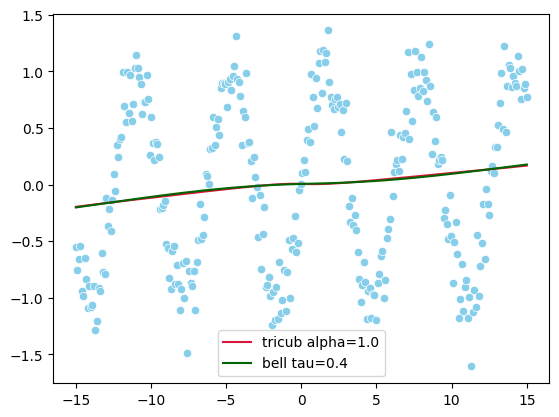

In [23]:
fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')

x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=1.0, deg=1)
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", label='tricub alpha=1.0')
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_est_tricub))

tau = 0.4
x_est_bell, y_est_bell = loess(x, y, kernel=bell_kernel, alpha=1.0, deg=1, tau=tau)
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", label=f'bell tau={tau}')
print("error bell = ", mean_squared_error(y_true=y, y_pred=y_est_bell))

plt.legend()
plt.show()

Если ошибки имеют симметричное распределение (с длинными хвостами) или есть выбросы, мы можем использовать более робастный LOESS.

Определим остатки:

$$
r_i = y_i - f(x_i).
$$

В нашем случае:

tricub tail share (robust z > 3) = 0.0
bell tail share (robust z > 3) = 0.0
tricub excess kurtosis = -1.256921876451598
bell excess kurtosis = -1.2573614743238242


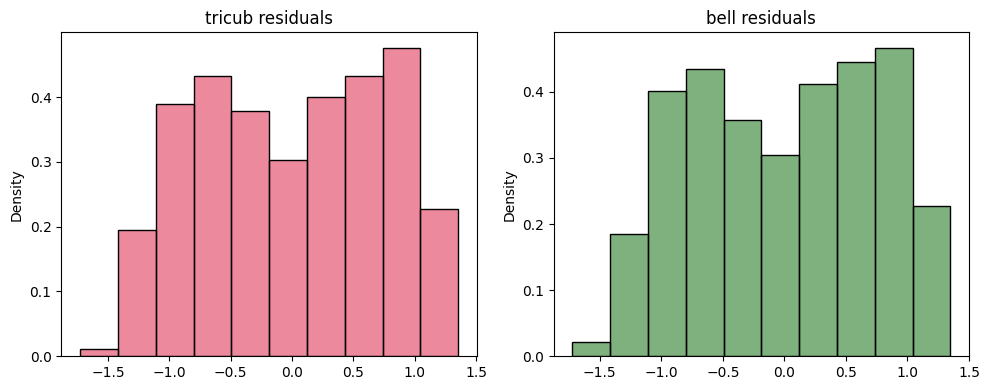

In [24]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[0])
axes[0].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[1])
axes[1].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)



Используем базовое ядро, заданное биквадратной функцией (bisquare):

$$
B(u) =
\begin{cases}
(1 - u^2)^2, & 0 \leq u < 1 \\
0, & \text{иначе.}
\end{cases}
$$

Пусть $m(r) = \mathrm{median}(|r|)$. Дополнительные веса тогда:

$$
\gamma_i = B\left(\frac{r_i}{6m}\right).
$$

Финальные веса принимают вид $\tilde{w}_i = \gamma_i\, w_i$.


In [25]:
def bicubic_kernel(dist):
    mask = dist < 1.0
    return ((1 - dist**2)**2) * mask

def get_robust_weights(y, y_pred):
    residuals = y - y_pred
    s = np.median(np.abs(residuals)) + 1e-12
    multiplier = np.abs(residuals) / (6.0 * s)
    multiplier = bicubic_kernel(multiplier)
    return multiplier

In [26]:
def loess_robust(x, y, kernel, alpha, deg, iterations, **kernel_params):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_pred = np.zeros(len(x))
    x_space = np.zeros_like(x)
    r_weights = np.ones(len(x))
    
    for it in range(iterations):
        for i, x_target in enumerate(x):
            u, x_span, y_span, ind_span = get_span(x, y, x_target, k)
            w = kernel(u, **kernel_params)
            w = w * r_weights[ind_span]
            p = solve(x_span, y_span, w, deg=deg)
            y_pred[i] = np.polyval(p, x_target)
            x_space[i] = x_target
        if it < iterations - 1:
            r_weights = get_robust_weights(y, y_pred)
    
    return x_space, y_pred

Построим данные, у которых действительно будут проблемы:

In [27]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)
y[5:10] -= 0.6
y[45:50] += 1.1
y[-30] += 1.
x[-45:-40] -= 0.1

x[145] += 1.1

x[-89:-80] -= 0.4


In [28]:
x_est_bell , y_est_bell = loess(x, y, kernel=bell_kernel, alpha=0.05, deg=1, tau=0.3)
x_est_tricub , y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)

Посмотрим, какие результаты мы получили:

tricub tail share (robust z > 3) = 0.01
bell tail share (robust z > 3) = 0.01
tricub excess kurtosis = 1.0925518836862542
bell excess kurtosis = 0.9972206126456511


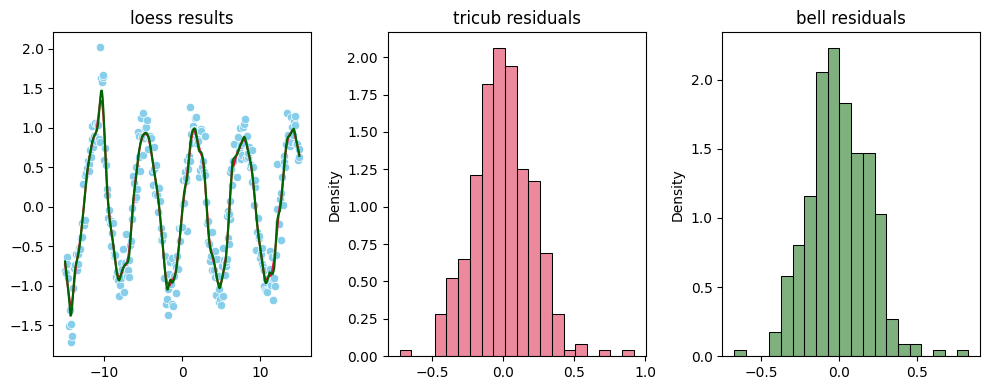

In [29]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[0])

sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", ax=axes[0])
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", ax=axes[0])
axes[0].set_title("loess results")
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[1])
axes[1].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[2])
axes[2].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)


Здесь уже видно, что есть тяжелые хвосты у остатков, попробуем применить робастную версию LOESS.

error =  0.05173687754390805


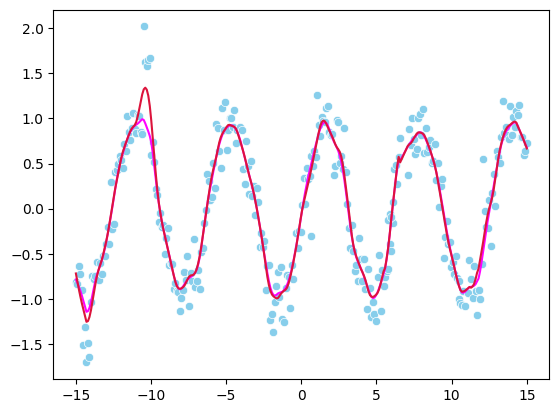

In [30]:
tau = 0.4

x_est, y_est = loess_robust(x, y, kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=tau)
sns.lineplot(x=x_est, y=y_est, color="magenta")
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson")

sns.scatterplot(x=x, y=y, color ='skyblue')

print("error = ", mean_squared_error(y_true=y, y_pred=y_est))

Задание: попробуйте другие ядра и постройте loess для разных данных с ними. Для каких особенностей данных подходят разные ядра?

In [31]:
def epanechnikov_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, 0.75 * (1 - abs_dist**2), 0.0)

def bisquare_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, (1 - abs_dist**2)**2, 0.0)

def triweight_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, (1 - abs_dist**2)**3, 0.0)

Рассмотрим и уже знакомую нам задачу предсказания стоимости.

In [32]:
data_path = "D:\data\ml"
data = pd.read_csv("/Users/lubimaya/Desktop/programming/ml_2026/spbu_ml_2026/data/realestate.txt", sep="\t")

data = data[["SalePrice", "SqFeet", "Lot"]]
data = np.log(data)
X_train, X_test, y_train, y_test = train_test_split(data[["SqFeet"]], data["SalePrice"])

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_train)
loess_x, loess_y = loess_robust(X_train.values.astype(float).ravel(), y_train.values.astype(float).ravel(), kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=tau)
loess_x_naive , loess_y_naive = loess(X_train.values.astype(float).ravel(), y_train.values.astype(float).ravel(), kernel=bell_kernel, alpha=0.05, deg=1, tau=tau)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dw/k7m_br6s4hz846j1dx_hjjz40000gq/T/ipykernel_22123/925813709.py:1: SyntaxWarning: invalid escape sequence '\d'
  data_path = "D:\data\ml"


--
--
Linear Regression error:  0.05356445325337977
loess error =  0.043406570278003466


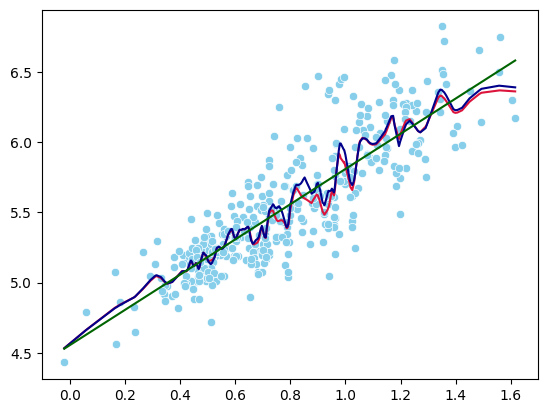

In [33]:
tau = 0.4

print('--')
sns.lineplot(x=loess_x, y=loess_y , color="crimson")
print('--')
sns.lineplot(x=loess_x_naive, y= loess_y_naive , color ='darkblue')
sns.lineplot(x=X_train.values.astype(float).ravel(), y= preds.ravel() , color ='darkgreen')
sns.scatterplot(x=X_train.values.astype(float).ravel(), y=y_train.values.astype(float).ravel() , color ='skyblue')
print("Linear Regression error: ", mean_squared_error(y_true=y_train.values.astype(float).ravel(), y_pred=preds))
print("loess error = ", mean_squared_error(y_true=y_train.values.astype(float).ravel(), y_pred=loess_y_naive))

## KDE

В LOESS ядро задаёт веса точек при локальной регрессии. В **ядерной оценке плотности (KDE)** ядро задаёт форму вклада каждой наблюдаемой точки в оценку **плотности** $f(x)$ по выборке $X_1,\ldots,X_n$:

$\hat{f}(x)=\frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x-X_i}{h}\right)$. 

В `sklearn.neighbors.KernelDensity` доступно несколько видов ядер, см. [документацию](https://scikit-learn.org/stable/modules/density.html).  При этом KDE реализовано и в skipy со statsmodels, причем вы можете уыидеть, что они содержат методы для поиска наилучших параметров.

Построим KDE для остатков линейной регрессии на обучающей выборке, чтобы связать оценку плотности с уже построенной линейной моделью.

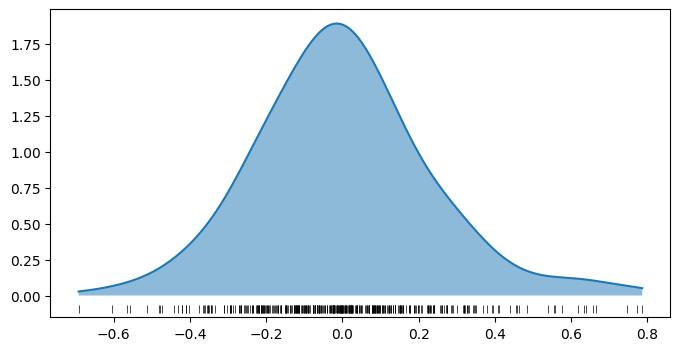

In [34]:
from sklearn.neighbors import KernelDensity

residuals = y_train.values.astype(float).ravel() - preds.ravel()
n = len(residuals)
bw = 1.06 * residuals.std(ddof=1) * (n ** (-0.2))
x_d = np.linspace(residuals.min(), residuals.max(), 500)
kde = KernelDensity(bandwidth=bw, kernel="gaussian")
kde.fit(residuals[:, None])
density = np.exp(kde.score_samples(x_d[:, None]))
fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_d, density, alpha=0.5)
ax.plot(x_d, density)
ax.plot(residuals, np.full_like(residuals, -density.max() * 0.05), "|k", markeredgewidth=0.5)
ax.set_ylim(bottom=-density.max() * 0.08)
plt.show()

Рассмотрим, возможно, более интересную задачу - попробуем отрисовать ареалы двух видов животных - ленивцев и лесных хомячков.

In [35]:
from sklearn.datasets import fetch_species_distributions

data = fetch_species_distributions()

# Get matrices/arrays of species IDs and locations
latlon = np.vstack([data.train['dd lat'],
                    data.train['dd long']]).T
species = np.array([d.decode('ascii').startswith('micro')
                    for d in data.train['species']], dtype='int')

In [36]:
y_min, y_max = data.train['dd lat'].min(), data.train['dd lat'].max()
x_min, x_max = data.train['dd long'].min(), data.train['dd long'].max()

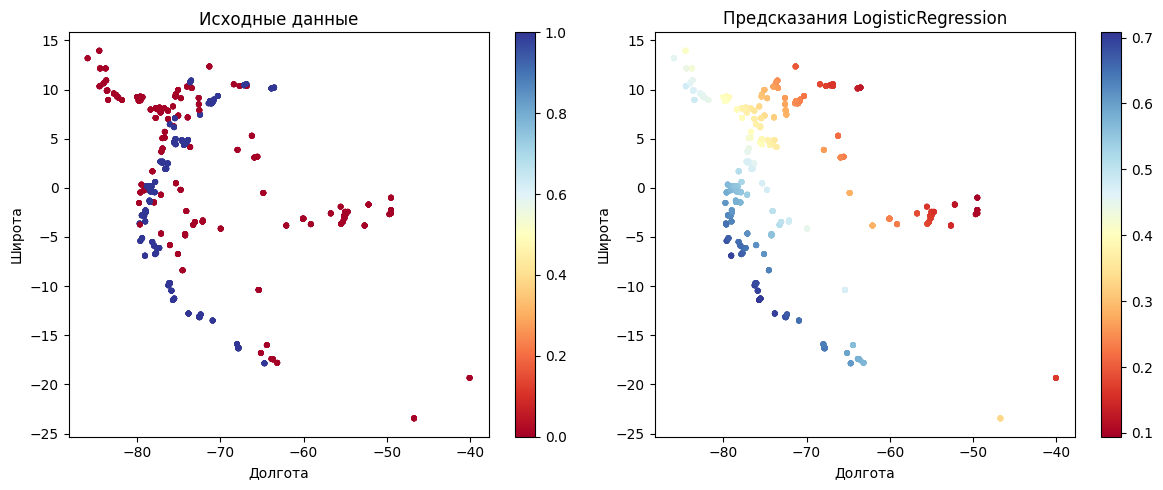

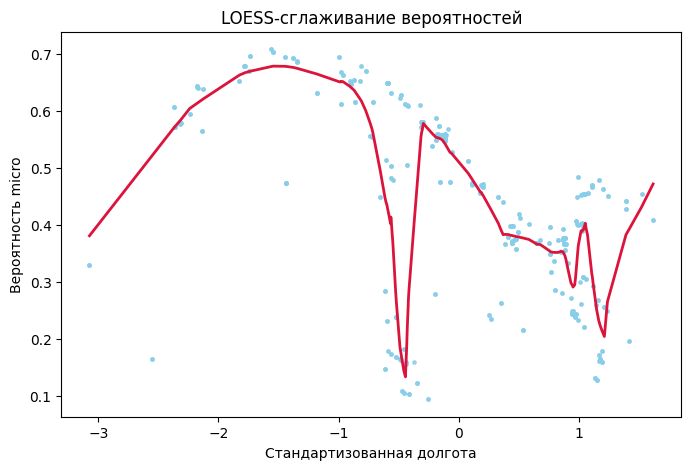

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
latlon_scaled = scaler.fit_transform(latlon)

model = LogisticRegression().fit(latlon_scaled, species)
preds = model.predict_proba(latlon_scaled)[:, 1]

x_unique = latlon_scaled[:, 0]
y_unique = latlon_scaled[:, 1]

loess_x, loess_y = loess_robust(
    x_unique, preds,
    kernel=bell_kernel,
    alpha=0.1,
    deg=1,
    iterations=3,
    tau=0.5
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(latlon[:, 1], latlon[:, 0], c=species, cmap='RdYlBu', s=10)
axes[0].set_title('Исходные данные')
axes[0].set_xlabel('Долгота')
axes[0].set_ylabel('Широта')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(latlon[:, 1], latlon[:, 0], c=preds, cmap='RdYlBu', s=10)
axes[1].set_title('Предсказания LogisticRegression')
axes[1].set_xlabel('Долгота')
axes[1].set_ylabel('Широта')
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 5))
sort_idx = np.argsort(x_unique)
plt.scatter(x_unique, preds, alpha=0.3, s=5, color='skyblue')
plt.plot(loess_x[sort_idx], loess_y[sort_idx], color='crimson', linewidth=2)
plt.xlabel('Стандартизованная долгота')
plt.ylabel('Вероятность micro')
plt.title('LOESS-сглаживание вероятностей')
plt.show()

In [38]:
def construct_grids(batch):
    xmin = batch.x_left_lower_corner + batch.grid_size
    xmax = xmin + batch.Nx * batch.grid_size
    ymin = batch.y_left_lower_corner + batch.grid_size
    ymax = ymin + batch.Ny * batch.grid_size

    xgrid = np.arange(xmin, xmax, batch.grid_size)
    ygrid = np.arange(ymin, ymax, batch.grid_size)

    return (xgrid, ygrid)

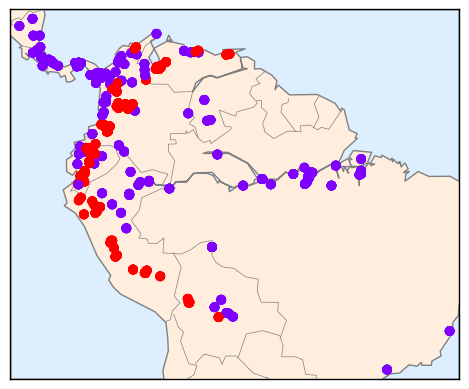

In [39]:
from mpl_toolkits.basemap import Basemap

# plot coastlines with basemap
m = Basemap(projection='cyl', resolution='c',
            llcrnrlat=y_min - 1, urcrnrlat=y_max + 1,
            llcrnrlon=x_min -1, urcrnrlon=x_max + 1)
m.drawmapboundary(fill_color='#DDEEFF')
m.fillcontinents(color='#FFEEDD')
m.drawcoastlines(color='gray', zorder=2)
m.drawcountries(color='gray', zorder=2)

# plot locations
m.scatter(latlon[:, 1], latlon[:, 0], zorder=3,
          c=species, cmap='rainbow', latlon=True);

К сожалению, это не дает хорошего представления о плотности вида, поскольку точки ареала вида могут перекрываться.

Давайте воспользуемся ядерной оценкой плотности, чтобы показать это распределение более понятным способом: как плавное указание плотности на карте. Поскольку система координат здесь лежит на сферической поверхности, а не на плоской плоскости, мы будем использовать метрику расстояния haversinus, которая будет правильно представлять расстояния на искривленной поверхности.


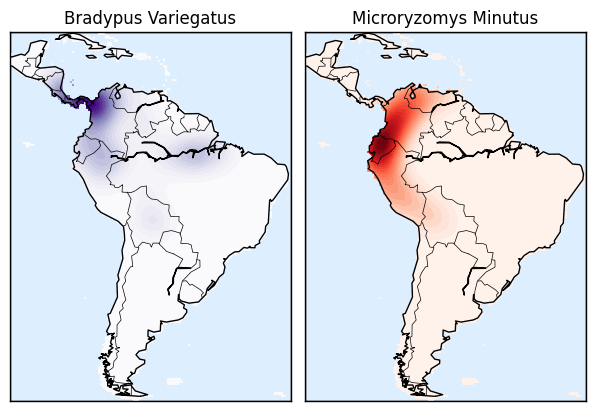

In [40]:
# Set up the data grid for the contour plot

xgrid, ygrid = construct_grids(data)

X, Y = np.meshgrid(xgrid[::5], ygrid[::5][::-1])

land_reference = data.coverages[6][::5, ::5]
land_mask = (land_reference > -9999).ravel()
xy = np.vstack([Y.ravel(), X.ravel()]).T
xy = np.radians(xy[land_mask])

# Create two side-by-side plots
fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05)
species_names = ['Bradypus Variegatus', 'Microryzomys Minutus']
cmaps = ['Purples', 'Reds']

for i, axi in enumerate(ax):
    axi.set_title(species_names[i])

    # plot coastlines with basemap
    m = Basemap(projection='cyl', llcrnrlat=Y.min(),
                urcrnrlat=Y.max(), llcrnrlon=X.min(),
                urcrnrlon=X.max(), resolution='c', ax=axi)
    m.drawmapboundary(fill_color='#DDEEFF')
    m.drawcoastlines()
    m.drawcountries()

    # construct a spherical kernel density estimate of the distribution
    # use metric='haversine'
    kde = KernelDensity(bandwidth=0.05, kernel="gaussian", metric='haversine') #
    # fit kde, don't forget to convert coords to radians
    kde.fit(np.radians(latlon[species == i]))

    # evaluate only on the land: -9999 indicates ocean
    Z = np.full(land_mask.shape[0], -9999.0)
    Z[land_mask] = np.exp(kde.score_samples(xy)) # exp of kde result
    Z = Z.reshape(X.shape)

    # plot contours of the density
    levels = np.linspace(0, Z.max(), 25)
    axi.contourf(X, Y, Z, levels=levels, cmap=cmaps[i])

Мы видим, что география видов действительно отличается, при этом можно видеть, где сконцентрировано больше всего особей. Так, даже сейчас мы можем попробовать вывести какие-то правила определеняи видов, и это без обучения!

Задание: напищите функцию KDE вручную, опробуйте на каком-нибудь датасете.

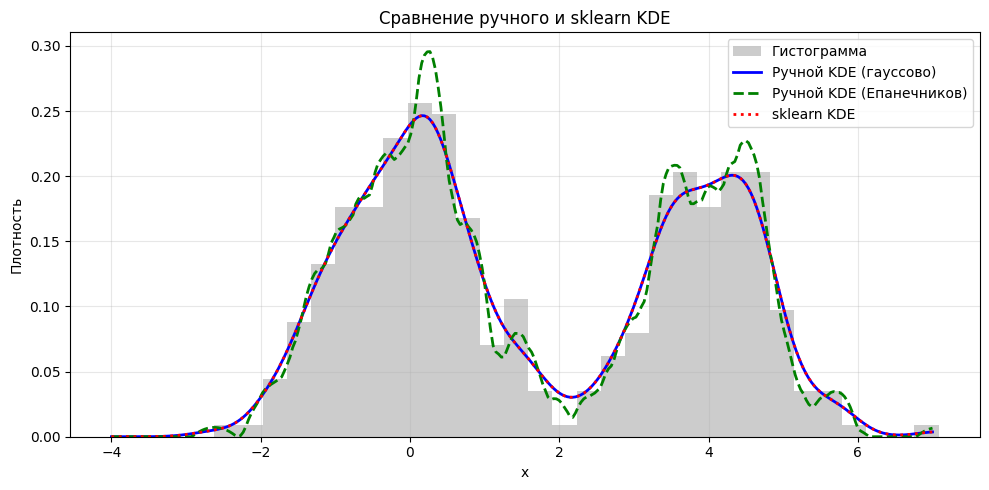

Макс. разница между ручным и sklearn: 1.6653345369377348e-15


In [41]:
def manual_kde(x, data, bandwidth, kernel='gaussian'):
    n = len(data)
    d = len(x)
    
    if kernel == 'gaussian':
        def gaussian_kernel(u):
            return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        
        densities = np.zeros(d)
        for i in range(d):
            u = (x[i] - data) / bandwidth
            densities[i] = np.sum(gaussian_kernel(u)) / (n * bandwidth)
    
    elif kernel == 'epanechnikov':
        def epanechnikov_kernel(u):
            return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0)
        
        densities = np.zeros(d)
        for i in range(d):
            u = (x[i] - data) / bandwidth
            densities[i] = np.sum(epanechnikov_kernel(u)) / (n * bandwidth)
    
    return densities

np.random.seed(42)
data1 = np.random.normal(0, 1, 200)
data2 = np.random.normal(4, 0.8, 150)
data_combined = np.concatenate([data1, data2])

x_grid = np.linspace(-4, 7, 300)
bw = 0.3

kde_manual_gauss = manual_kde(x_grid, data_combined, bw, kernel='gaussian')
kde_manual_epa = manual_kde(x_grid, data_combined, bw, kernel='epanechnikov')

from sklearn.neighbors import KernelDensity
kde_sklearn = KernelDensity(bandwidth=bw, kernel='gaussian')
kde_sklearn.fit(data_combined[:, None])
kde_sklearn_vals = np.exp(kde_sklearn.score_samples(x_grid[:, None]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data_combined, bins=30, density=True, alpha=0.4, color='gray', label='Гистограмма')
ax.plot(x_grid, kde_manual_gauss, 'b-', linewidth=2, label='Ручной KDE (гауссово)')
ax.plot(x_grid, kde_manual_epa, 'g--', linewidth=2, label='Ручной KDE (Епанечников)')
ax.plot(x_grid, kde_sklearn_vals, 'r:', linewidth=2, label='sklearn KDE')
ax.set_xlabel('x')
ax.set_ylabel('Плотность')
ax.set_title('Сравнение ручного и sklearn KDE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Макс. разница между ручным и sklearn:", 
      np.max(np.abs(kde_manual_gauss - kde_sklearn_vals)))